# Stream fitting

### Dimitra Giantsidi & Nolan Ottele 2026

This code measures the length and average width of a detected stream of a galaxy at different angles. It requires the matched-filter detection and the Segment outputs of the galaxy. It also calculates the length-to-width ratio vs. declination of observation. "Object of interest" refers to the stream throughout the code.

In [1]:
# import all necessary libraries
from pathlib import Path as path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import re
import math
import os
import copy
import matplotlib as mpl
from scipy.optimize import curve_fit
import heapq
from scipy.signal import convolve2d

In [4]:
# enter the name of the galaxy, its matched-filter depth, distance and resolution, and desired number of angles
box = 'storm'
gal_num = '2'
galaxy_name = f'{box}_{gal_num}'
D = 2000
size_kpc = 40
pdist = (size_kpc/D) * (180/np.pi)
depth="26p5"
distance=2000
pix=8000
numangles=24
initial_guess = [440, 3, 1, 7.7, -0.2, 0, -0.2]
mask_cutoff = 0.05

In [5]:
# 2d fitting function, pass to the func below - copy past from dimitra + nolan 
def twoD_exponential(coords, A, h, q, x_offset, y_offset, theta, C):
    """ The 2D exponential model function.

    Params:
        coords (2D array of floats):
            The 2D array of data in the XY plane.
        A (float):
            Amplitude.
        h (float):
            Scale length.
        q (float):
            Axis ratio (minor/major; related to orientation).
        x_offset (float):
            distance of the center of the galaxy from the center of the image on the x-axis.
        y_offset (float):
            distance of the center of the galaxy from the center of the image on the y-axis.
        theta (float):
            Rotation angle in viewing plane (0 means major axis is along the x-axis, pi/2 means major axis is along the y-axis).
        C (float):
            Offset from background (should be about 0).

    Returns:
        exp_fit (array of floats):
            The calculated 2D exponential fit values.
    """
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    exp_fit = A * np.exp(-r/h) + C
    return exp_fit

In [6]:
# define the necessary file paths to get the data from
sd_outputs_path = (f'../substructure_detection/sd_outputs')
segmented_path = path(f'{sd_outputs_path}/Segment/{galaxy_name}/segmented')
centers_path = path(f'{sd_outputs_path}/twod_exp_fit/{galaxy_name}/centers.txt')
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{depth}_{distance}/{galaxy_name}/')

In [7]:
# define necessary values to be updated
area_of_interest = np.zeros((numangles, 89, 89), dtype=bool)
min_obj = 0
max_obj = 0
my_extent = [-60,60,-60,60]

In [8]:
def centers(file_name, galaxy_name):
    """ Identifies the center of the galaxy at a specific angle.
    
    Requires the 2D exponential fit algorithm to have run first and for the existence of the centers path with the centers file
    formatted exactly as defined in the 2D exponential fit algorithm. It reads the declination and azimuth of the file_name, finds
    their match in the file and their respective x- and y- coordinates.
    
    Args:
        file_name (f string):
            The name of the file of the galaxy of interest of which the first two instances of numbers 
            should be the declination and the azimuth of observation in this order (separation by period is acceptable).
        galaxy_name (f string):
            The name of the galaxy of interest.

    Returns:
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
    """
    
    x_center = 0
    y_center = 0
    numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', file_name)]
    angles = numbers[1:-1]
    d = angles[0]
    a = angles[1]
    target_message = 'center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}'
    
    with open(f'{centers_path}', 'r') as file:
        for line in file:
            if target_message in line: # assumes there is only one instance of the correct message
                parts = line.strip().split(':')
                coords = parts[1].split(',')
                x_center = float(coords[0].strip())
                y_center = float(coords[1].strip())
                
    return x_center, y_center

In [44]:
def area_of_interest_finder(Z_fitted, image_data, d):
    # postprocessing - finding the max, subtract model, mask leftover central bins - this might need to go in favor of setting bins w/i X% of max to zero, no fitting at all?
    z_fit_max = np.max(Z_fitted)
    print("z_fit_max:",mask_cutoff * z_fit_max)
    mask_thresh = mask_cutoff * z_fit_max # set a cutoff here - for inner pixels that are not well modeleld by the exponential, set to 0
    mask = Z_fitted < mask_thresh
    residual = sig_array - Z_fitted # subtracts the fit from the whole mf map, fit was on higher confience region
    masked_residual = residual.copy()
    masked_residual[~mask] = 0 # after subtracting, set values that are above some cutoff to zero

    # hilighting pixels after model subtraction that are still above the 4 sigma level AND have at least N neighbours that are not None
    significant_mask = masked_residual >= 4. # masking the residual w/ some cutoff significance, here is 4 sigma
    # lowering the value above will result in images very similar to Segment's!
    significant_masked_residual = masked_residual.copy()
    significant_masked_residual[~significant_mask] = None
    kernel = np.ones((3,3)) # n-neighbors kernel from stack overflow 
    kernel[1,1] = 0
    n_neighbors = convolve2d(significant_mask, kernel, mode='same', boundary='fill') # do convolution
    neighbor_mask = n_neighbors < 4 # chuck significant pixels with less than N neighbors that are also significant - here N is 4
    neighbor_residual = masked_residual.copy()
    neighbor_residual[neighbor_mask] = None # set to none for visualizing 

    # now using an edge detection kernel to get the boundary
    fil = np.ones((3,3)) * -1
    fil[1,1] = 8
    convolution = convolve2d(neighbor_mask,fil, mode='same', boundary='fill',fillvalue=None)
    yedges,xedges = np.where(convolution > 1) # in pixel coordinates, values above 1 represent an edge w/ this kernel

    xedges_arcmin = None # used in conditional later for plotting 
    if (convolution > 1).any() == True: # conditional for the case of no blobs with edges to detect, if False then skip 
        xedges_arcmin = (xedges - int(pdist/pix) - 0.5) * (pix)
        np.append(xedges_arcmin,xedges_arcmin[-1]) # matplotlib Path objects need the first and last point to be the same so the loop closes
        yedges_arcmin = (yedges - int(pdist/pix) - 0.5) * (pix)
        np.append(yedges_arcmin,yedges_arcmin[-1])

        #### this can be returned / writtin out to use for future analysis ####
        edges_arcmin = np.array([xedges_arcmin,yedges_arcmin]).T 

    #### clipping the sig_array above and below some value, not a good solution and this shows why 
    sig_clip_mask = ((sig_array >= 4.) & (sig_array < 20.)) # mask for whole 2D array 
    sigarr_clip = sig_array.copy()
    sigarr_clip[~sig_clip_mask] = None

    return masked_residual, significant_masked_residual, neighbor_residual

In [45]:
def radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest):
    """ Calculates the density-weighted average radius of the area of interest within each given bin.

    Args:
        n_of_interest (int):
            Number of pixels of interest.
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_of_interest (empty array):
            To be filled with the x-coordinates of the pixels of interest.
        y_of_interest (empty array):
            To be filled with the y-coordinates of the pixels of interest.

    Returns:
        avg_radii (array of floats):
            Array of length equal to n_bins containing the average radius of the object of interest within each bin.
        bin_size (float):
            The size of each bin.
    """
    
    x_delta = [n - x_center for n in x_of_interest]
    y_delta = [n - y_center for n in y_of_interest]

    theta = [0] * n_of_interest

    for i in range(len(x_delta)):
        theta[i] = np.mod(math.atan2(y_delta[i],x_delta[i]), 2*np.pi)

    bin_size = 2*np.pi/n_bins

    ang_bin = [0] * n_of_interest
    for i in range(len(theta)):
        ang_bin[i] = int(np.floor(theta[i]/bin_size))

    radii = [0] * n_of_interest
    for i in range(n_of_interest):
        radii[i] = np.sqrt(x_delta[i]**2 + y_delta[i]**2)

    avg_radii = [0] * n_bins

    for j in range(n_bins):
        radii_sum = 0
        radii_counter = 0
        for i in range(len(ang_bin)):
            if ang_bin[i] == j:
                radii_sum = radii_sum + radii[i]
                radii_counter = radii_counter + 1
        if radii_counter == 0:
            radii_average = 0
        else:
            radii_average = radii_sum / radii_counter
        avg_radii[j] = radii_average
    avg_radii = np.array(avg_radii)

    return avg_radii, bin_size

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=0.0_a=0.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 17.89908301876458


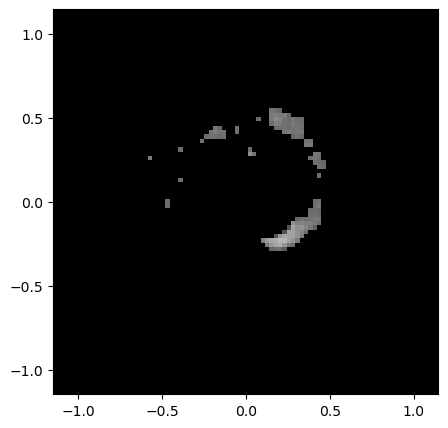

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=17.0_a=222.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 17.749918908852035


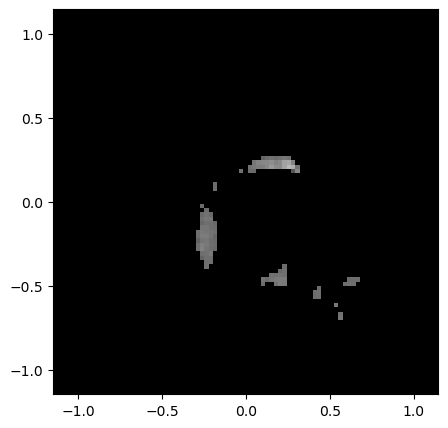

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=24.1_a=85.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 22.176753139537894


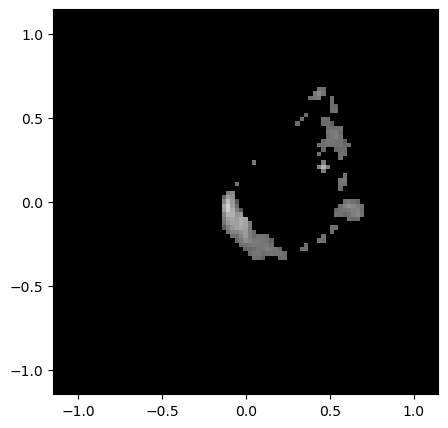

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=29.6_a=307.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 21.074320678626023


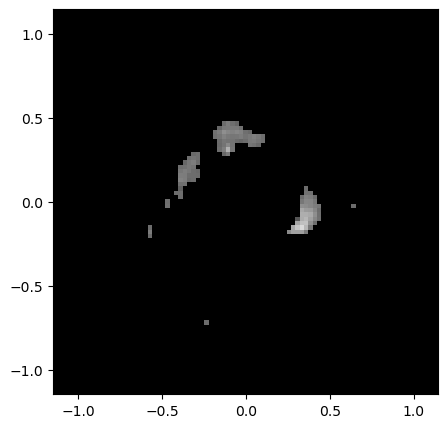

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=34.3_a=170.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 20.81151196787042


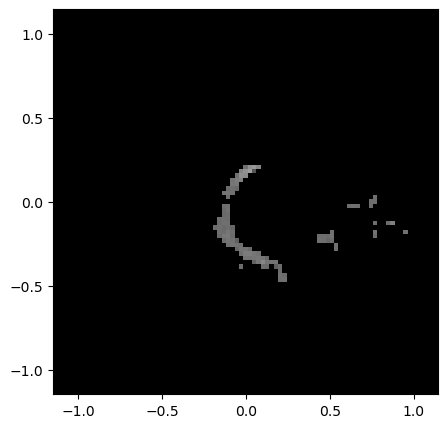

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=38.5_a=32.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 23.52554354475029


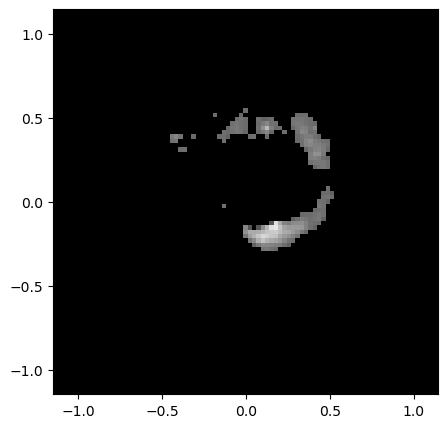

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=42.3_a=255.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 21.933086030714044


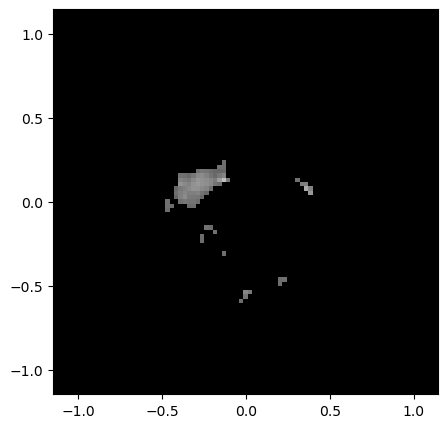

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=45.9_a=117.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 26.042621341674522


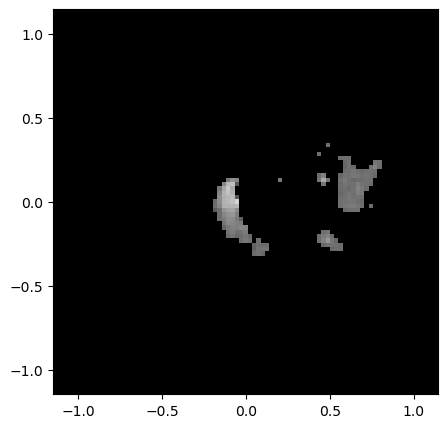

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=49.3_a=339.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 27.275697578548915


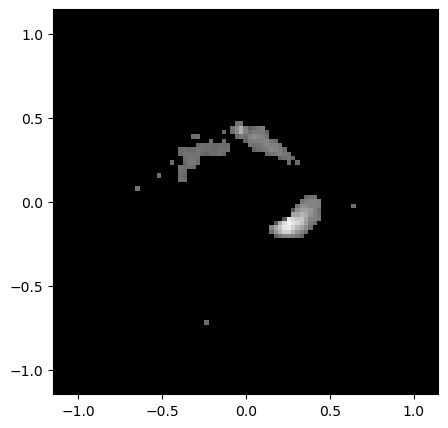

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=52.5_a=202.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 23.812389730674823


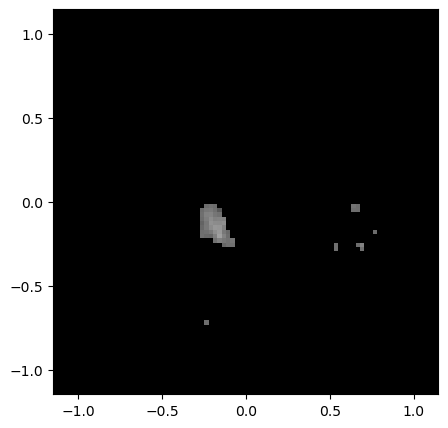

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=55.6_a=64.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 31.346017987075694


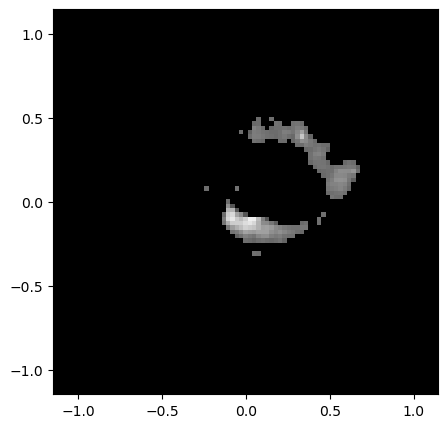

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=58.6_a=287.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 27.260511939247166


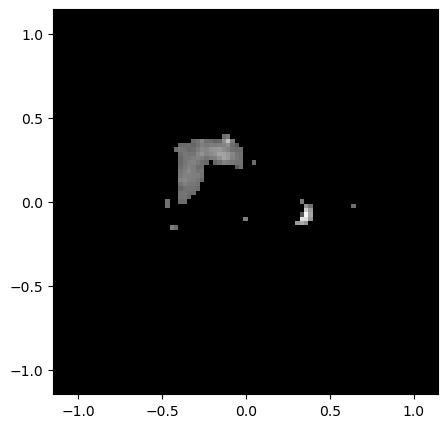

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=61.4_a=149.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 32.83838706197558


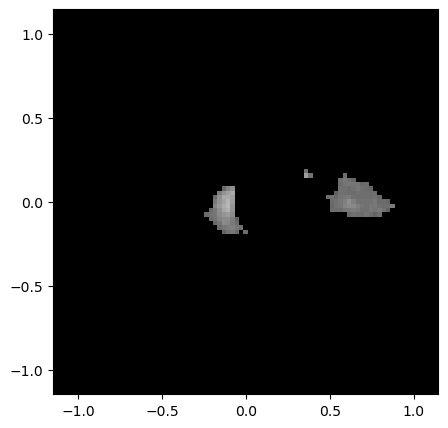

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=64.2_a=12.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 38.34937655154828


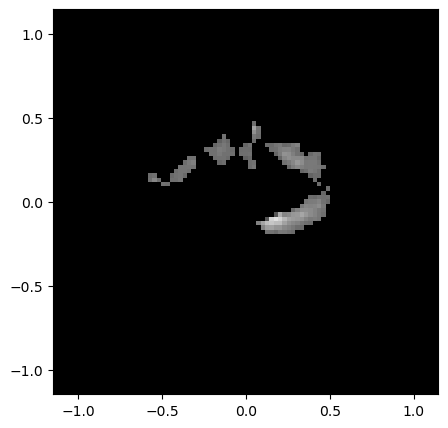

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=67.0_a=234.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 29.52602001334341


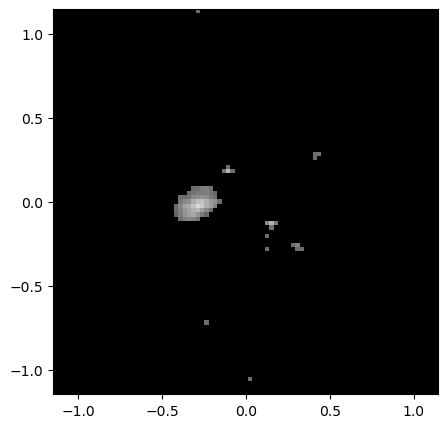

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=69.6_a=97.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 40.12002732293141


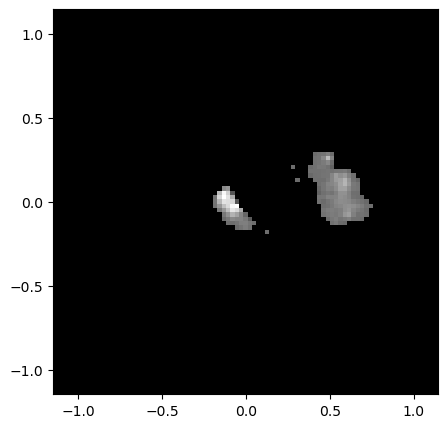

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=72.3_a=319.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 43.024533594071976


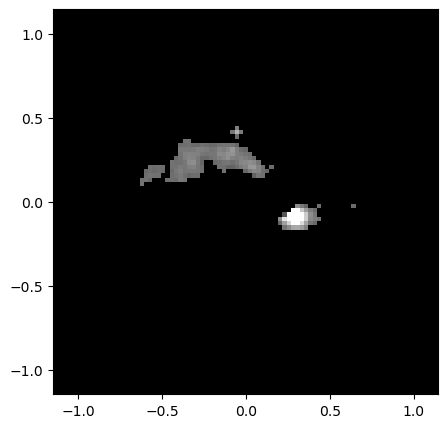

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=74.9_a=182.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 39.742647192977365


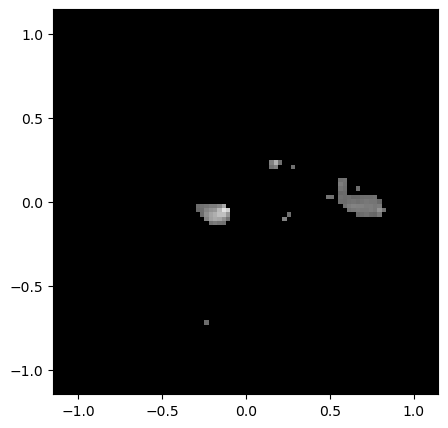

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=77.4_a=44.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 41.70584847479588


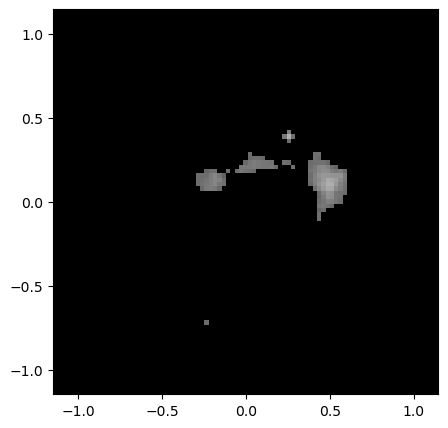

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=80.0_a=267.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 37.90925587435597


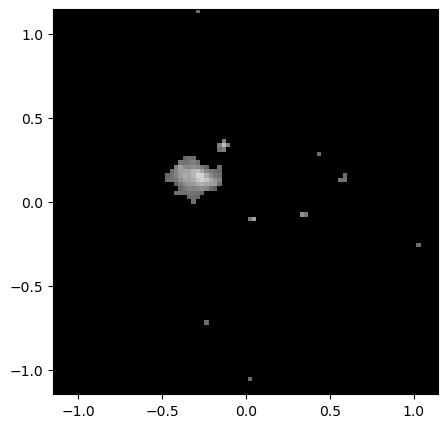

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=82.5_a=129.8_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 46.02621255575512


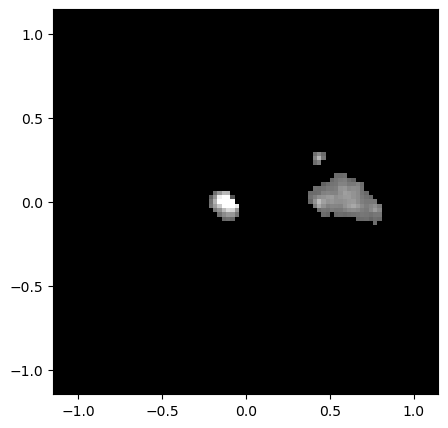

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=85.0_a=352.3_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 49.96675122750889


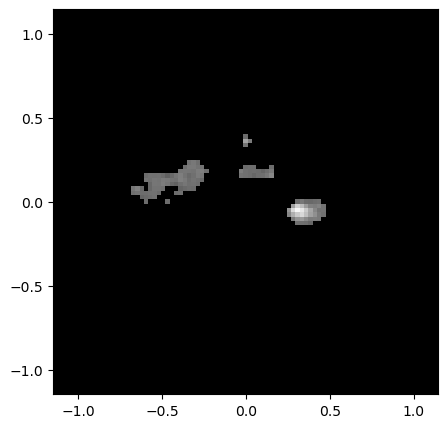

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=87.5_a=214.8_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 45.38552380930018


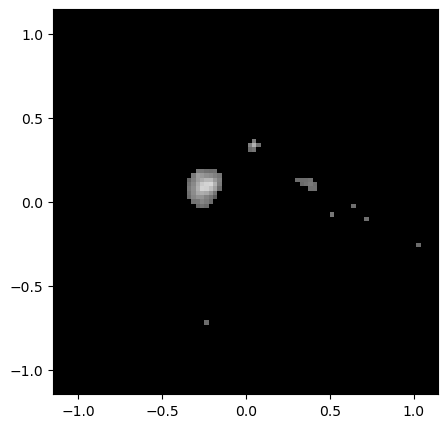

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=90.0_a=77.3_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 42.462500242569064


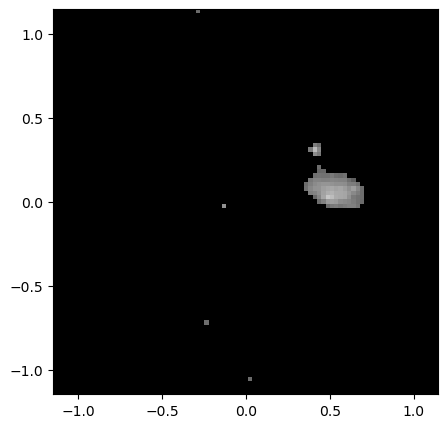

In [46]:
current_rotation = 0

# isolate the area of interest, split it into angular bins and calculate its density-weighted average radius within each bin
for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]

        # load the segmented fits file
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        image_data = hdul[0].data

        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)

        # plot the bins (only for visual aid purposes)
        n_bins = 32

        # print the structure to see where the data lives
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        hdul.info()
        
        # extract the target data arrays
        image_data = hdul[0].data
        
        # save the extracted arrays into a compressed .npz file
        npz_path = path(f'mf_npz_catalogs/{galaxy_name}')
        npz_path.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(f"{npz_path}/{file.stem}.npz", sig_array=image_data)

        npz = f'{npz_path}/{file.stem}.npz'
        sig_array = np.load(npz)['sig_array']
        levels = [4,5,7,10,20,50,100,150]
    
        # generate grid of the same size as the mf map to fit over 
        x_line = np.linspace(-60, 60, 89)
        y_line = np.linspace(-60, 60, 89)
        X, Y = np.meshgrid(x_line, y_line)
        
        # Flatten the arrays to 1-D for curve_fit
        x_flat = X.ravel()
        y_flat = Y.ravel()
        z_flat = sig_array.ravel()
        independent_vars = np.vstack((x_flat, y_flat))
    
        # do the fit 
        fitted_params, covariance = curve_fit(
                f=twoD_exponential, 
                xdata=independent_vars, 
                ydata=z_flat, 
                p0=initial_guess
            )
    
        Z_fitted = twoD_exponential((X, Y), *fitted_params)

        masked_residual, significant_masked_residual, neighbor_residual = area_of_interest_finder(Z_fitted, image_data, d)
        
        fig,axs = plt.subplots(nrows=1,ncols=1)
        fig.set_figheight(5)
        fig.set_figwidth(20)

        axs.set_facecolor("black")

        axs.imshow(significant_masked_residual[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                    cmap = 'gray', vmin = -15, vmax = 30)
        axs.imshow(neighbor_residual[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                        cmap = 'gray', vmin = -15, vmax = 30)

        # calculate the average readius of each bin
        # avg_radii = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)

        # print(significant_masked_residual[::-1,:])
        # print(np.unique(significant_masked_residual[::-1,:]))
        
        current_rotation = current_rotation + 1
        plt.show()
        plt.close()

In [12]:
def find_large_outliers(data, multiplier=1.5):
    """ Finds only large, extreme upper outliers while ignoring small values.

    Args:
        data (array of numbers):
            The desired data to be checked for large outliers.

    Returns:
        outlier_values (number or array of numbers):
            The numbers identified as large outliers.
    """
    data = np.array(data)
    
    # Calculate upper quartile parameters
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    # Establish a high upper fence
    upper_bound = q3 + (multiplier * iqr)
    
    # Extract only values exceeding this high threshold
    outlier_indices = np.where(data > upper_bound)
    outlier_values = data[outlier_indices]
    
    return outlier_values

In [13]:
def ray_cells_in_grid(x0, y0, dx, dy, width, height):
    """Amanatides-Woo traversal algorithm. Copied from the internet. Calculates the grid pixels a line goes through.
    Basic idea is to calculate parametrically which edge of the box a line is approaching at any given time.

    Args:
        x0 (int):
            Starting x value in grid coordinates
        y0 (int):
            Starting y value in grid coordinates
        dx (int):
            Change in x with respect to time. Really just numerator of slope.
        dy (int): 
            Change in y with respect to time. Really just denominator of slope.
        width (int):
            X size of the grid.
        height (int):
            Y size of the grid

    Returns:
        cells (2D array of ints):
            A list of cells the line goes through, including the first cell it starts in.     
    """
    if dx == 0 and dy == 0:
        raise ValueError("direction vector (dx, dy) cannot be (0, 0)")
 
    i, j = math.floor(x0), math.floor(y0)
    if not (0 <= i < width and 0 <= j < height):
        return []
    cells = [(x0,y0),(i, j)]
 
    step_i = 1 if dx > 0 else (-1 if dx < 0 else 0)
    step_j = 1 if dy > 0 else (-1 if dy < 0 else 0)
 
    # tMaxX/tMaxY: parametric distance to the next vertical/horizontal
    # grid line. tDeltaX/tDeltaY: how much that increases per cell.
    if dx != 0:
        next_x = i + (1 if dx > 0 else 0)
        tMaxX = (next_x - x0) / dx
        tDeltaX = abs(1.0 / dx)
    else:
        tMaxX = math.inf
        tDeltaX = math.inf
 
    if dy != 0:
        next_y = j + (1 if dy > 0 else 0)
        tMaxY = (next_y - y0) / dy
        tDeltaY = abs(1.0 / dy)
    else:
        tMaxY = math.inf
        tDeltaY = math.inf
 
    while True:
        if tMaxX < tMaxY:
            tMaxX += tDeltaX
            i += step_i
        elif tMaxY < tMaxX:
            tMaxY += tDeltaY
            j += step_j
        else:
            tMaxX += tDeltaX
            tMaxY += tDeltaY
            i += step_i
            j += step_j
 
        if not (0 <= i < width and 0 <= j < height):
            break
        cells.append((i, j))
        if len(cells)>=11:
            break
 
    return cells

In [14]:
def length_calc(n_bins, x_center, y_center, x_ang, y_ang):
    """ Calculates the total length of the stream.

    Args:
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        total_dist (float):
            The total calculated length of the stream.
    """

    total_dist = 0
    
    for i in range(n_bins):
        
        # calculate the separation between a pair of points
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
        
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) # distance for this specific pair
            total_dist = total_dist + dist  # total accumulated distance

            plt.plot([x_ang[p1], x_ang[p2]], [y_ang[p1], y_ang[p2]], color = '#72BCD4', alpha=0.5) # line from point 1 to point 2

    return total_dist

In [15]:
def width_calc(image_data, n_bins, x_ang, y_ang):
    """ Calculates the width of bins of the stream.

    Args:
        image_data (hdul.data):
            The extracted data of a matched-filtered galaxy (from a .fits format).
        n_bins (int):
            Number of bins.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        stream_width_counter (int):
            The number of widths calculated.
        stream_width_total (float):
            The sum of the widths calculated.
    """

    stream_width = 0
    stream_width_counter = 0
    stream_width_total = 0

    for i in range(n_bins):
    
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
    
        x_mid = (x_ang[p1]+x_ang[p2])/2
        y_mid = (y_ang[p1]+y_ang[p2])/2
        #plt.scatter(x_mid, y_mid, color = 'green', s=20) # plots midpoints between any two given points
    
        x_mid_as_grid = round((60+x_mid)*89/120) # converts midpoints into grid coordinates
        y_mid_as_grid = 89-round((60+y_mid)*89/120)
    
        # calculate the separation between a pair of points
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) # distance for this specific pair
    
        if x_sep == 0 and y_sep == 0: 
            print(f"{i}. Invalid. No separation.") # prevents crashing in case of non-existing average radius/radii
            
        else:
            cells_1 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, y_sep, x_sep, 89, 89) # lists all cells in line in one direction from muidpoing
            cells_2 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, -y_sep, -x_sep, 89, 89) # lists all cells in opposite direction
    
            emtpy_limit = 5 # limit for consecutive empty encounters. WE STRONGLY ADVISE TO ADJUST FOR EACH GALAXY
            far_limit = 11 # limit for parts of the stream being too close to each other
            
            # identify stopping points due to empty encounters in both directions
            limit_1 = 0
            for n in range(far_limit):
                if (image_data[cells_1[n][1]][cells_1[n][0]]) == 0:
                    break_counter = 0
                    for m in range(emtpy_limit):
                        if n+m <= len(cells_1):
                            if (image_data[cells_1[n+m-1][1]][cells_1[n+m-1][0]]) == 0:
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_1 = n
                    if break_counter == emtpy_limit:
                        break
                limit_1 = n
    
            limit_2 = 0
            for n in range(far_limit):
                if (image_data[cells_2[n][1]][cells_2[n][0]]) == 0:
                    break_counter = 0
                    for m in range(emtpy_limit):
                        if n+m <= len(cells_2):
                            if (image_data[cells_2[n+m-1][1]][cells_2[n+m-1][0]]) == 0:
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_2 = n
                    if break_counter == emtpy_limit:
                        break
                limit_2 = n
    
            # apply stopping points in both directions
            cells_1_culled = [[x, y] for x, y in cells_1[:limit_1] if not ((image_data[y][x]) == 0)]
            cells_2_culled = [[x, y] for x, y in cells_2[:limit_2] if not ((image_data[y][x]) == 0)]
    
            if len(cells_1_culled)!=0 and len(cells_2_culled)!=0: # case where the area extends in both directions
                
                cell_first = cells_1_culled[-1] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)==0 and len(cells_2_culled)!=0: # case where the area does not extend in one direction
    
                cell_first = cells_2_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordinates of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)!=0 and len(cells_2_culled)==0: # case where the area does not extend in the other direction
    
                cell_first = cells_1_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_1_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
                
            else: # case where the area does not extend in either direction
                 print(f"{i}. Invalid. No width.")

    return stream_width_counter, stream_width_total

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No separation.
30. Invalid. No separation.
31. Invalid. No separation.
Average Width: nan
Total Distance: 0
Length/Width Ratio: nan


NameError: name 'numpix' is not defined

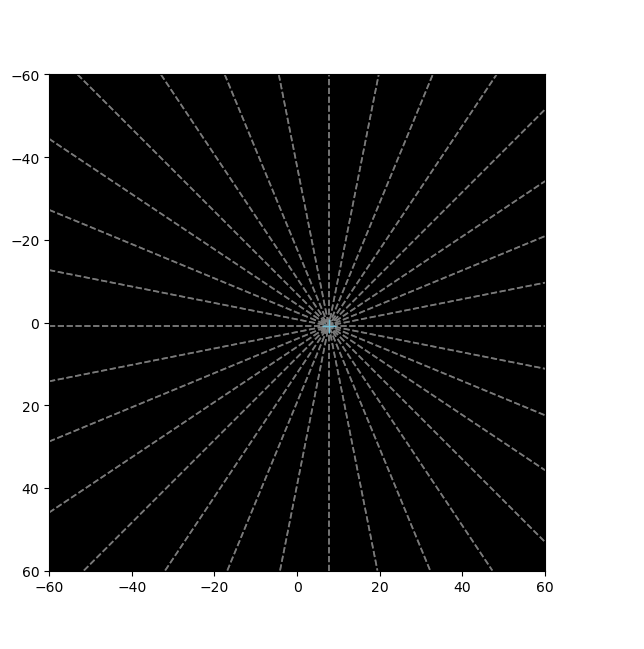

In [16]:
# define necessary values to be updated every time this is ran
ratio = 0
length_array = []
width_array = []
ratio_array = []
current_rotation = 0

for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        # load the matched-filter detection output fits file
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        image_data = np.squeeze(hdul[0].data)

        # extract the area_of_interest
        image_data[~area_of_interest[current_rotation, :, :]] = 0
        
        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)
        
        # plot the bins (only for visual help)
        max_length = 89
        n_bins = 32  
        angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        for angle in angles:
            if np.isclose(angle, np.pi/2) or np.isclose(angle, 3*np.pi/2):
                ax.axvline(x=x_center, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
            else:
                slope = np.tan(angle)
                ax.axline(
                    (x_center, y_center), 
                    slope=slope, 
                    color='gray', 
                    linestyle='--', 
                    linewidth=1.2, 
                    alpha=0.8
                )
        
        ax.plot(x_center, y_center, color='#72BCD4', marker='+', markersize=10, label='Center')
        
        # identify outliers
        outliers = find_large_outliers(np.unique(image_data))
        outlier_mask = np.isin(image_data, outliers)
        image_data[outlier_mask] = 0
        
        # identify coordinates of interest
        x_of_interest = []
        y_of_interest = []
        val_of_interest = []
        
        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if ~(val == 0):
                    val_of_interest.append(val)
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)
        
        # number of pixels of interest
        n_of_interest = len(x_of_interest)
        
        # calculate the average readius of each bin
        avg_radii, bin_size = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)
        
        # plot points for the average radius at the angular midpoint of each bin
        angles = np.linspace(0, 2*np.pi, n_bins, endpoint=False)
        angles = (angles + bin_size / 2)
        
        x_ang = avg_radii * np.cos(angles) + x_center
        y_ang = -avg_radii * np.sin(angles) + y_center
        
        cmap = plt.cm.gray.copy() # brighter areas represent higher star density
        cmap.set_bad(color='black')
        
        # set value scale AFTER the center is removed
        min_obj = np.min(image_data)
        max_obj = np.max(image_data)
        
        plt.scatter(x_ang, y_ang, color='#72BCD4', marker='+', s=50, alpha=0.5)
        
        # calculate stream length
        total_dist = length_calc(n_bins, x_center, y_center, x_ang, y_ang)
        
        # calculate stream width
        stream_width_counter, stream_width_total = width_calc(image_data, n_bins, x_ang, y_ang)
        
        # calculate average stream width
        if stream_width_counter != 0:
            avg_width = stream_width_total/stream_width_counter
            ratio = total_dist/avg_width
        else:
            avg_width = np.nan
            ratio = np.nan
        print(f"Average Width: {avg_width}")
        print(f"Total Distance: {total_dist}")
        print(f"Length/Width Ratio: {ratio}")
        
        # plot the image with lengths and widths
        current_cmap = copy.copy(mpl.colormaps['gray'])
        current_cmap.set_bad(color='black')
        
        plt.imshow(image_data, extent=[-60,60,-60,60], cmap = current_cmap, vmin=0, vmax=10)
        
        length_array.append(total_dist)
        width_array.append(avg_width)
        ratio_array.append(ratio)
        
        cbar = plt.colorbar(orientation='vertical')
        if cbar.solids is not None:
            cbar.solids.set_alpha(0)
        if hasattr(cbar, 'lines') and isinstance(cbar.lines, list):
            for line in cbar.lines:
                line.set_alpha(0)
        cbar.outline.set_alpha(0)
        cbar.ax.tick_params(axis='both', colors=(0,0,0,0), labelcolor=(0,0,0,0))
        #cbar.set_label('Stellar Density Level', rotation=270, labelpad=15)
        
        plt.gca().xaxis.set_visible(True)
        plt.gca().yaxis.set_visible(True)
        
        ax.invert_yaxis()
        stfit_path = path(f'stfit_outputs/{galaxy_name}/fitted/stfit_{galaxy_name}_fitted_d={d}_a={a}_pix={numpix}.png')
        stfit_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f'{stfit_path}', dpi=300, bbox_inches='tight', transparent=True)
        plt.show()
        hdul.close()
        
        current_rotation = current_rotation + 1

In [256]:
def fibonacci_angler(n):
    """ Calculates n equally-spaced angles around a sphere.

    Args:
        n (int):
            The desired number of angles.

    Returns:
        declination_array (array of floats):
            The declinations of the calculated angles.
        azimuthal_array (array of floats):
            The azimuthals of the calculated angles.
    """
    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/((n-1)) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    return declination_array, azimuthal_array

declination_array, azimuthal_array = fibonacci_angler(numangles)

In [257]:
def func_fit(theta, length, width):
    """ Ratio as a function of length and width, assuming that the stream is cylindrical.

    Args:
        theta ((array of) float(s)):
            Angle(s) of observation (either declination or azimuthal).
        length ((array of) float(s)):
            Length(s) of the stream.
        width ((array of) float(s)):
            Width(s) of the stream.

    Returns:
        ratio ((array of) float(s)):
            The length-to-width ratio(s) of the stream.
    """

    ratio = (length * np.cos(theta * np.pi / 180) + width * np.sin(theta * np.pi / 180)) / width
    
    return ratio

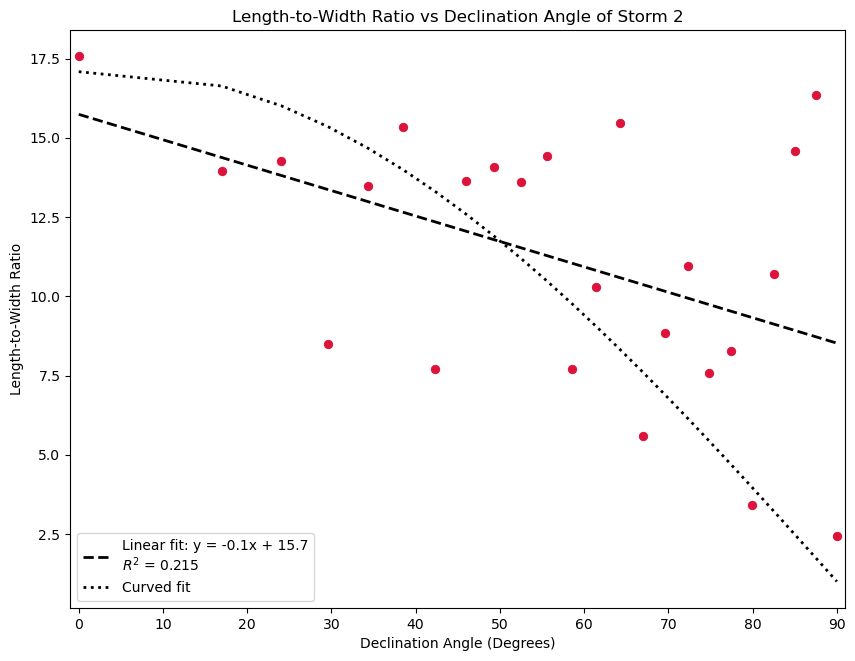

y= -0.08022935534256728 x + 15.742874125233621 , R^2= 0.21547333135147015


In [258]:
# plot and save the length-to-width ratio vs. declination graph with a linear and a curved fit

x = declination_array * 180 / (np.pi)
y = ratio_array

p0 = np.array([22,1])
popt, pcov = curve_fit(func_fit, x, y, p0)
our_plot = func_fit(x, popt[0], popt[1])

m, b = np.polyfit(x, y, deg=1)
y_pred = m * x + b

r_matrix = np.corrcoef(x, y)
r_value = r_matrix[0, 1]
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(10, 7.5))

ax.scatter(x, y, color='crimson', linewidth=0.7)
ax.plot(x, y_pred, color='black', linestyle='--', linewidth=2, \
        label=f'Linear fit: y = {m:.1f}x + {b:.1f}\n$R^2$ = {r_squared:.3f}')
ax.plot(x, our_plot, color='black', linestyle=':', linewidth=2, \
        label=f'Curved fit')
ax.set_xlim(left=-1, right=91)

ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

ax.set_xlabel("Declination Angle (Degrees)")
ax.set_ylabel("Length-to-Width Ratio")
ax.set_title("Length-to-Width Ratio vs Declination Angle of Storm 2")

ax.legend()

ratio_v_angle_path=path(f'stfit_outputs/{galaxy_name}')
ratio_v_angle_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(f'{ratio_v_angle_path}/lw_vs_dec.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print('y=', m, 'x +', b, ', R^2=', r_squared)

In [259]:
# Define the path to save the length, width and their ratio for every angle
lw_path = path(f'stfit_outputs/{galaxy_name}/lw.txt')
lw_path.parent.mkdir(parents=True, exist_ok=True)

In [260]:
# Save the length, width and their ratio for every angle
if os.path.exists(lw_path):
    os.remove(lw_path)

for i in range(len(ratio_array)):
    with open(f'{lw_path}', 'a') as file:   
        file.write('center of ' f'{galaxy_name}' ' at d=' f'{x[i]:.1f}' ': length=' f'{length_array[i]}' ', width=' f'{width_array[i]}' ', length-to-width ratio=' f'{ratio_array[i]}' '\n')